<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-09-06 21:16:18--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  40.6MB/s    in 6.2s    

2026-09-06 21:16:26 (32.5 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [76]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [4]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [5]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


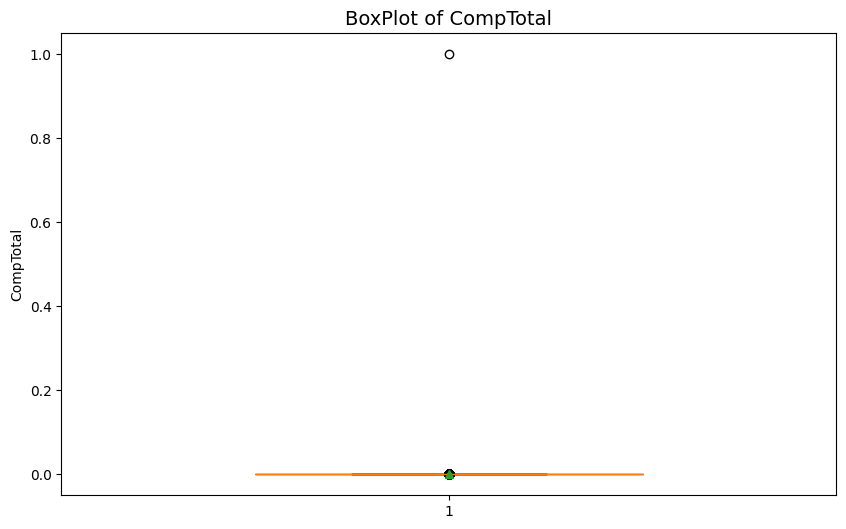

In [8]:
# your code goes here
QUERY = """
SELECT CompTotal
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.dropna(inplace=True)

df_normalized = (df - df.min()) / (df.max() - df.min())

plt.figure(figsize=(10, 6))
plt.boxplot(df_normalized, vert=True, patch_artist=True, 
            widths=0.5, showmeans=True)
plt.title('BoxPlot of CompTotal', fontsize=14)
plt.ylabel('CompTotal')
plt.savefig('Box_CT.png')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


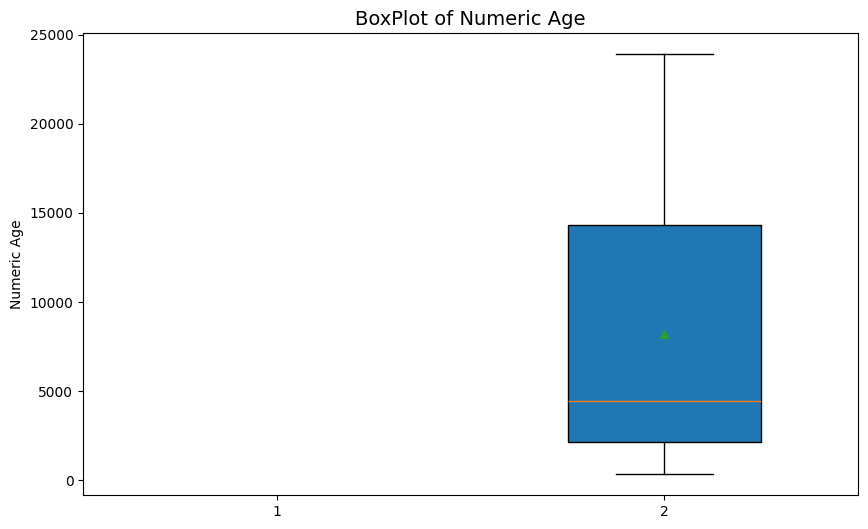

In [28]:
# your code goes here
QUERY = """
SELECT Age, COUNT(*) as Count 
FROM main
GROUP BY Age
"""

df = pd.read_sql_query(QUERY, conn)

age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None
}

df['Age'] = df['Age'].map(age_mapping)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
plt.figure(figsize=(10, 6))
plt.boxplot(df, vert=True, patch_artist=True, 
            widths=0.5, showmeans=True)
plt.title('BoxPlot of Numeric Age', fontsize=14)
plt.ylabel('Numeric Age')
plt.savefig('Box_NA.png')
plt.show()



### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


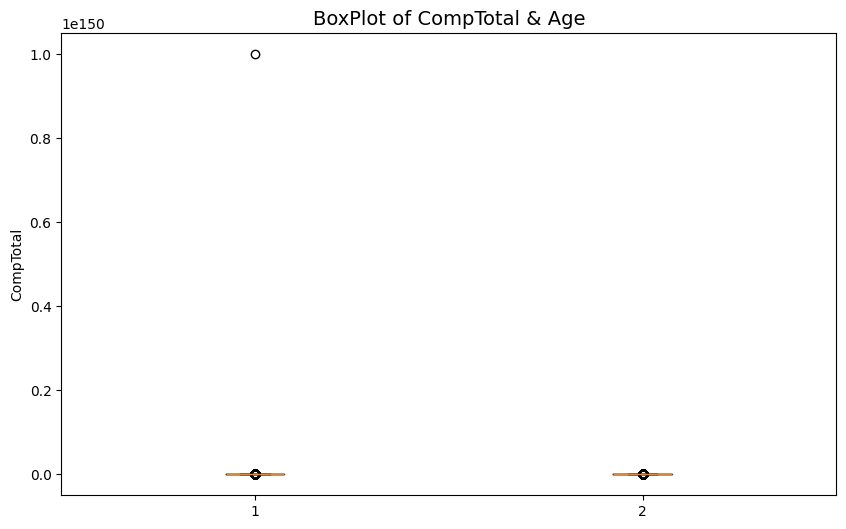

In [ ]:
# your code goes here
QUERY = """
SELECT CompTotal, Age
FROM main
"""

df = pd.read_sql_query(QUERY, conn)

age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None
}

df['Age'] = df['Age'].map(age_mapping)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df.dropna(inplace=True)

plt.figure(figsize=(10, 6))
plt.boxplot(df)
plt.title('BoxPlot of CompTotal & Age', fontsize=14)
plt.ylabel('CompTotal')
plt.savefig('Box_CT_NA.png')
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


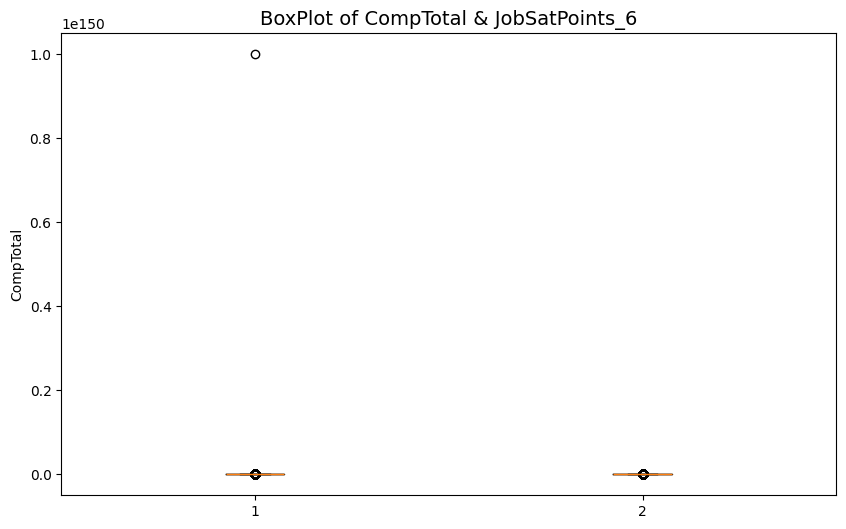

In [39]:
# your code goes here
QUERY = """
SELECT CompTotal, JobSatPoints_6
FROM main
"""

df1 = pd.read_sql_query(QUERY, conn)

df1.dropna(inplace=True)

plt.figure(figsize=(10, 6))
plt.boxplot(df1)
plt.title('BoxPlot of CompTotal & JobSatPoints_6', fontsize=14)
plt.ylabel('CompTotal')
plt.savefig('Box_CT_NA.png')
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_76203/3832604018.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=devtype_order, patch_artist=True,


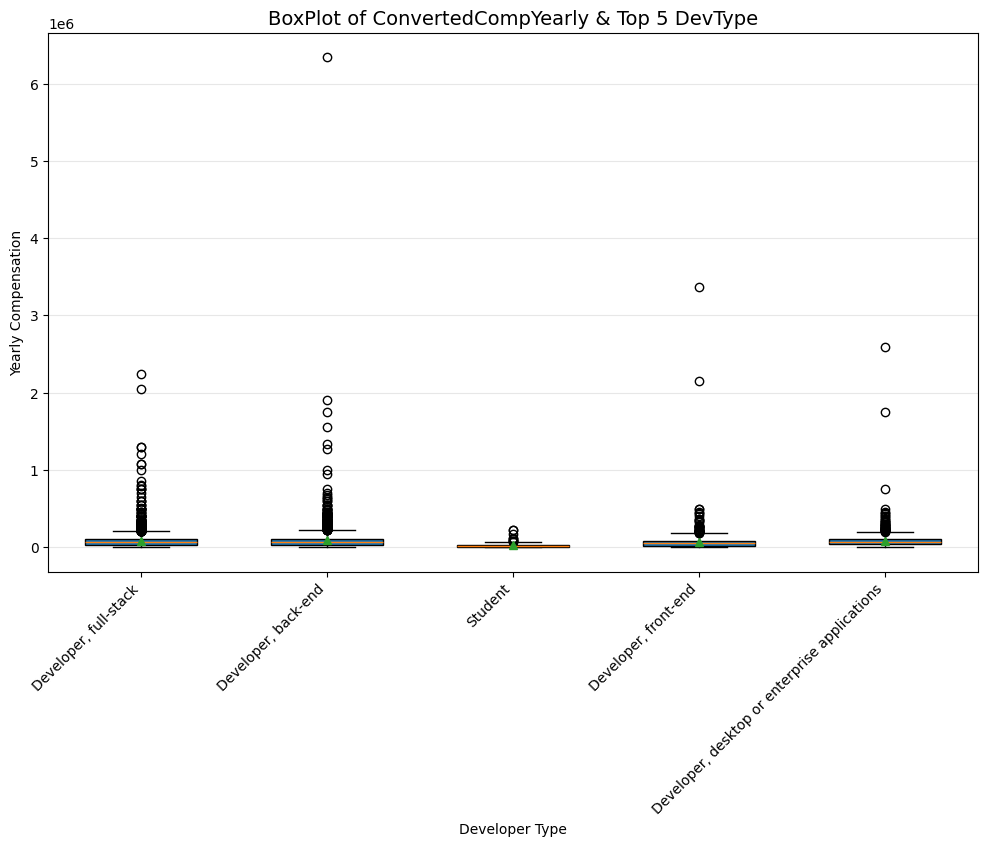

In [69]:
# your code goes here
QUERY = """
SELECT ConvertedCompYearly, DevType
FROM main
"""

df2 = pd.read_sql_query(QUERY, conn)

df2['ConvertedCompYearly'] = pd.to_numeric(df2['ConvertedCompYearly'], errors='coerce')

devtype_list = []
for devtypes in df2['DevType'].dropna():
    # Split by semicolon and strip whitespace
    types = [dt.strip() for dt in str(devtypes).split(';')]
    devtype_list.extend(types)

devtype_counts = pd.Series(devtype_list).value_counts()
top5_devtypes = devtype_counts.head(5)

expanded_data = []
for idx, row in df2.iterrows():
    if pd.notna(row['DevType']) and pd.notna(row['ConvertedCompYearly']):
        devtypes = [dt.strip() for dt in str(row['DevType']).split(';')]
        for devtype in devtypes:
            if devtype in top5_devtypes.index:
                expanded_data.append({
                    'DevType': devtype,
                    'ConvertedCompYearly': row['ConvertedCompYearly']
                })

df_expanded = pd.DataFrame(expanded_data)

fig, ax = plt.subplots(figsize=(12, 7))

# Using ax.boxplot with prepared data
devtype_order = top5_devtypes.index.tolist()
data_to_plot = [df_expanded[df_expanded['DevType'] == dt]['ConvertedCompYearly'].values 
                for dt in devtype_order]

bp = ax.boxplot(data_to_plot, labels=devtype_order, patch_artist=True,
                 widths=0.6, showmeans=True)
plt.title('BoxPlot of ConvertedCompYearly & Top 5 DevType', fontsize=14)
plt.ylabel('Yearly Compensation')
plt.xlabel('Developer Type')
plt.xticks(rotation=45, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.savefig('Box_CCT_5DT.png')
plt.show()



**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_76203/3972528676.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=country_order, patch_artist=True,


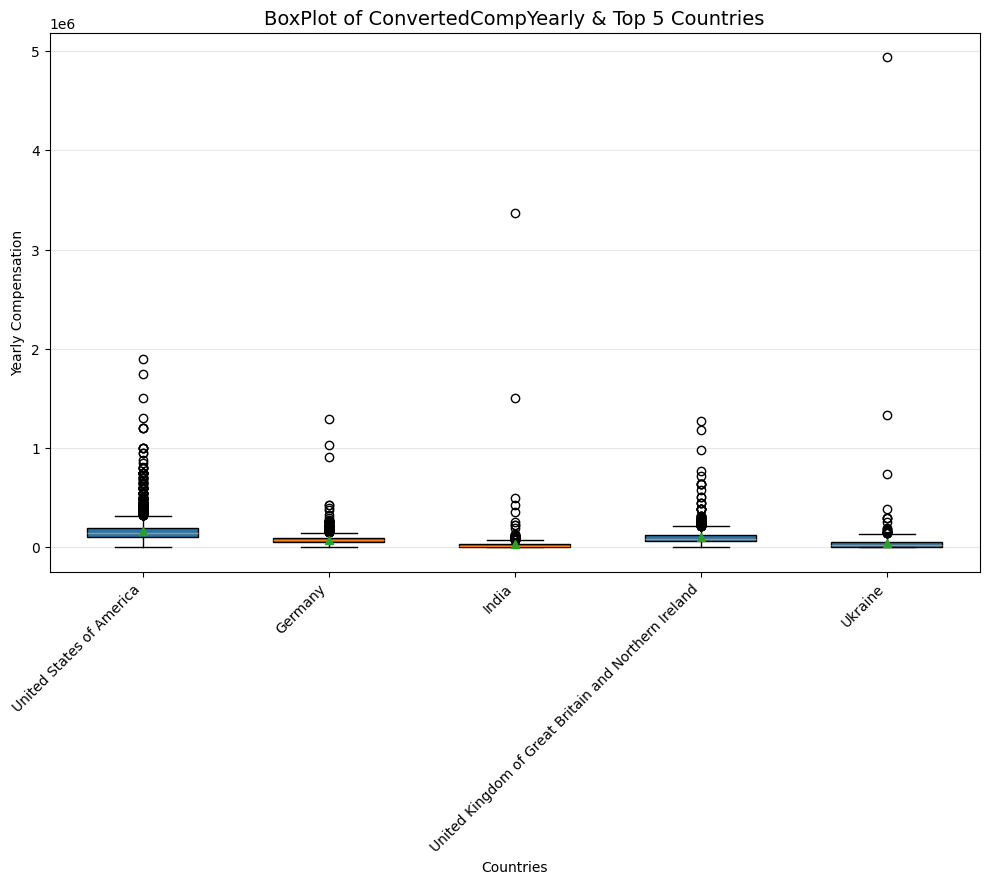

In [73]:
# your code goes here
QUERY = """
SELECT ConvertedCompYearly, Country
FROM main
"""

df3 = pd.read_sql_query(QUERY, conn)

df3['ConvertedCompYearly'] = pd.to_numeric(df3['ConvertedCompYearly'], errors='coerce')

country_counts = pd.Series(df3['Country']).value_counts()
top5_countries = country_counts.head(5)

expanded_data = []
for idx, row in df3.iterrows():
    if pd.notna(row['Country']) and pd.notna(row['ConvertedCompYearly']):
        countries = [dt.strip() for dt in str(row['Country']).split(';')]
        for country in countries:
            if country in top5_countries.index:
                expanded_data.append({
                    'Country': country,
                    'ConvertedCompYearly': row['ConvertedCompYearly']
                })

df_expanded = pd.DataFrame(expanded_data)

fig, ax = plt.subplots(figsize=(12, 7))

# Using ax.boxplot with prepared data
country_order = top5_countries.index.tolist()
data_to_plot = [df_expanded[df_expanded['Country'] == dt]['ConvertedCompYearly'].values 
                for dt in country_order]

bp = ax.boxplot(data_to_plot, labels=country_order, patch_artist=True,
                 widths=0.6, showmeans=True)

plt.title('BoxPlot of ConvertedCompYearly & Top 5 Countries', fontsize=14)
plt.ylabel('Yearly Compensation')
plt.xlabel('Countries')
plt.xticks(rotation=45, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.savefig('Box_CCT_5C.png')
plt.show()



### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


<Figure size 1000x600 with 0 Axes>

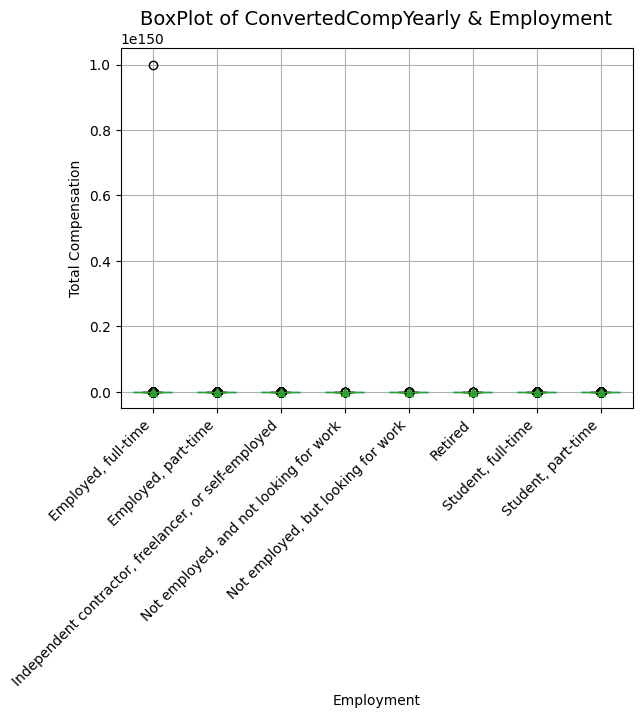

In [84]:
# your code goes here
QUERY = """
SELECT CompTotal, Employment
FROM main
"""

df4 = pd.read_sql_query(QUERY, conn)

df4.dropna(inplace=True)

df4['Employment_list'] = df4['Employment'].str.split(';')

df4_new = df4.explode('Employment_list').copy()
df4_new['Employment_clean'] = df4_new['Employment_list'].str.strip()
df4_new = df4_new[df4_new['Employment_clean'] != '']

plt.figure(figsize=(10, 6))
df4_new.boxplot(column='CompTotal', by='Employment_clean', patch_artist=True,
                 widths=0.6, showmeans=True)

plt.title('BoxPlot of ConvertedCompYearly & Employment', fontsize=14)
plt.suptitle("")
plt.ylabel('Total Compensation')
plt.xlabel('Employment')
plt.xticks(rotation=45, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.savefig('Box_CCT_E.png')
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


<Figure size 1000x600 with 0 Axes>

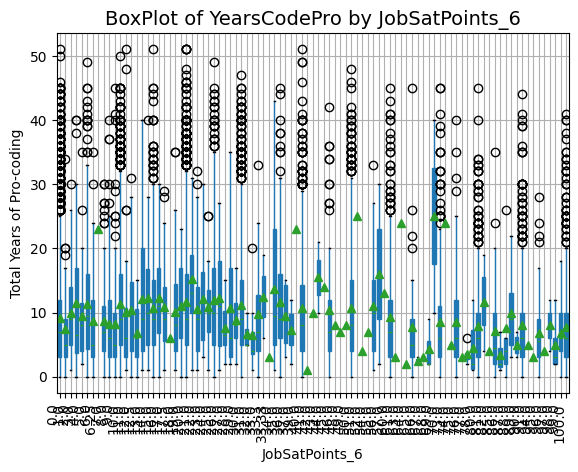

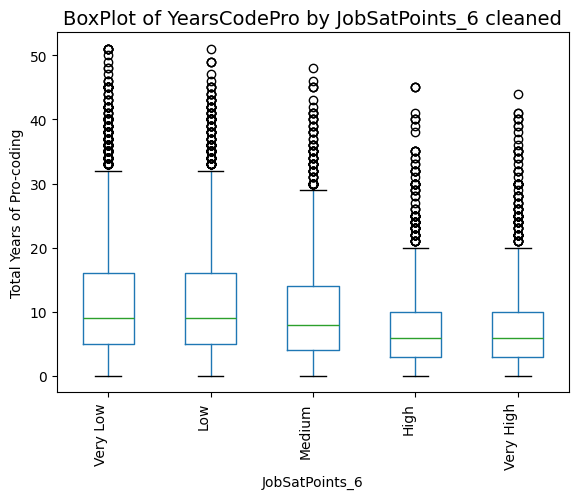

In [91]:
# your code goes here
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
"""

df5 = pd.read_sql_query(QUERY, conn)

df5.dropna(inplace=True)

df5['YearsCodePro'] = (
    df5['YearsCodePro'].replace(
        {"Less than 1 year": 0, "More than 50 years" : 51}
    ).astype(float)
)

plt.figure(figsize=(10, 6))
df5.boxplot(column='YearsCodePro', by='JobSatPoints_6', patch_artist=True,
                 widths=0.6, showmeans=True)

plt.title('BoxPlot of YearsCodePro by JobSatPoints_6', fontsize=14)
plt.suptitle("")
plt.ylabel('Total Years of Pro-coding')
plt.xlabel('JobSatPoints_6')
plt.xticks(rotation=90, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.savefig('Box_YCP_JSP6.png')
plt.show()

# clean version 
bins = [0, 20, 45, 65, 85, 100]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df6 = df5.copy()
df6['JobSatPoints_6'] = pd.cut(df6['JobSatPoints_6'], bins=bins, labels=labels)

df6.boxplot(
    column='YearsCodePro',
    by='JobSatPoints_6',
    grid=False
)

plt.title('BoxPlot of YearsCodePro by JobSatPoints_6 cleaned', fontsize=14)
plt.suptitle("")
plt.ylabel('Total Years of Pro-coding')
plt.xlabel('JobSatPoints_6')
plt.xticks(rotation=90, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.savefig('Box_YCP_JSP6_clean.png')
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [92]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
